# 3HDM-S₃ scalar parameter space in the soft-broken vacuum

**A research notebook, not a tutorial.** It assumes notebook 01 (the exact-S₃ scan: the
forced √3 alignment, the corrected boundedness conditions, the coupling-aware neutral cuts)
and notebook 02 §11 (the four soft quadratics, and why the quark sector needs them).
Conclusions here are *findings* and may be revised.

**The question:** notebook 01 scans the exactly-S₃ potential, whose tadpoles lock the
doublet-plane angle to $\varphi=60°$. Notebook 02 showed that this exact vacuum gives
$V_{us}=0$, and that soft S₃ breaking frees $\varphi$ and turns the Cabibbo angle on. What
scalar parameter space and spectrum survive the same theory and collider cuts once the
vacuum is released?

## What this notebook establishes

1. **Soft is not small** (§1). The soft terms are sampled wide and the near-S₃ regime is
   read off as a limit. A parametrization pole at φ = 45° is found and avoided (§2).
2. **φ ∈ (0, π/3) is a fundamental domain** under S₃. Notebook 02's quark-fit vacuum sits at
   φ = 53.4° inside it (§3).
3. **The spectrum machinery generalizes.** Goldstones stay isolated, the CP-even sector
   becomes a full 3×3 with no gauge-phobic state, and the exact-S₃ limit is recovered
   (§4).
4. **2021 viable points from 110M.** The soft-broken spectrum is **decoupling-like**, and
   the exact scan's light gauge-phobic scalars do not survive generic soft breaking (§6).

In [ ]:
import json, logging, math, sys, time
from pathlib import Path

import numpy as np
import sympy as sp
import matplotlib
logging.getLogger("matplotlib").setLevel(logging.CRITICAL)  # a broken personal
import matplotlib.pyplot as plt                             # stylelib file is noisy

sys.path.insert(0, str(Path.cwd()))
from model import (build_model, spectrum_function, hvv_function, aligned_vevs,
                   soft_vevs, draft_r, soft_free_names, soft_solved_names,
                   soft_mass_function, soft_spectrum_function,
                   _geometric_rotation_numeric, _neutral_symbols,
                   SPECTRUM_KEYS, SOFT_SPECTRUM_KEYS, SOFT_CP_EVEN_KEYS, V_EW)
from constraints import KAPPA2_MIN, M_LEP_ZH, XI2_LEP_FLOOR
import scan_soft
import derive as dv                      # the by-hand derivation vocabulary

plt.rcParams.update({"figure.dpi": 110, "font.size": 9,
                     "axes.grid": True, "grid.alpha": 0.3})
sp.init_printing(use_latex="mathjax")

ok = dv.ok
ledger = dv.Ledger("05 — S₃-3HDM scalar parameter space in the soft-broken vacuum")
print("electroweak scale:", V_EW, "GeV")

electroweak scale: 246.0 GeV


---
## 1. What "soft" does and does not mean

The soft-broken potential adds to notebook 01's $V$ the four CP-conserving, gauge-invariant
quadratics that break S₃ (notebook 02 §11):

$$
V_{\rm soft}=m_{D1}^2\,(x_{11}-x_{22})\;-\;m_{D2}^2\,(x_{12}+x_{21})
\;+\;m_{S1}^2\,(x_{S1}+x_{1S})\;+\;m_{S2}^2\,(x_{S2}+x_{2S}),
$$

i.e. the $\mathbf2$ of $\mathbf2\otimes\mathbf2$ and the doublet $H_S^\dagger H_i$, each
contracted with a constant "spurion" doublet of mass² coefficients.

**Soft is a statement about operator dimension, not about size.** Every S₃-breaking operator
here has dimension 2. The quartics, and in notebook 02 the Yukawas, stay exactly S₃-invariant,
so no loop can produce an S₃-breaking quartic: the spurions carry mass dimension 2, and a
dimension-4 operator needs a dimensionless coefficient, which they cannot supply. The soft
terms therefore renormalize only in proportion to themselves. Two things follow:

* setting them to zero restores S₃, so *small* values are technically natural in 't Hooft's
  sense ['tHooft80]. Natural means stable, not required;
* nothing requires them to be small. A soft term of order $v^2$, or of order (TeV)², is just
  as consistent. Large ones give heavy states whose masses are set by the soft scale, the
  analogue of the 2HDM's $m_{12}^2$ decoupling regime.

So the scan below samples the soft terms **wide**. The near-S₃ regime is not imposed as a
prior. It is read off afterwards from per-point breaking tags, as a limit of the general
case.

One consequence carries over from notebook 01 unchanged: **boundedness from below and tree
unitarity depend on the quartics alone**, so `strict_bfb_mask`, `unitarity_mask` and the 12-d
backstop apply to λ exactly as before.

In [ ]:
t0 = time.time()
ms = build_model(soft=True, soft_solve_for="mD1sq")
m = build_model()                         # the exact-S3 model of notebook 01
print("built in %.1f s" % (time.time() - t0))
print("soft quadratics      :", list(ms.softs))
print("alignment imposed    :", ms.align, "  <- empty: nothing forces it")
print("tadpoles solve for   :", soft_solved_names(ms))
print("free soft inputs     :", soft_free_names(ms))
assert ms.align == {} and soft_free_names(ms) == ["mD2sq", "mS1sq", "mS2sq"]
ok("three tadpoles, three unknowns (mu0^2, mu1^2, mD1^2): an ordinary system, no alignment")

built in 0.8 s
soft quadratics      : ['mD1sq', 'mD2sq', 'mS1sq', 'mS2sq']
alignment imposed    : {}   <- empty: nothing forces it
tadpoles solve for   : ['mD1sq', 'mu0sq', 'mu1sq']
free soft inputs     : ['mD2sq', 'mS1sq', 'mS2sq']
✓ three tadpoles, three unknowns (mu0^2, mu1^2, mD1^2): an ordinary system, no alignment


---
## 2. The released tadpoles

### 2.1 Which soft term to solve for is not a free choice

There are three tadpole equations and five quadratic parameters ($\mu_0^2$, $\mu_1^2$, and
two of the four soft terms that enter the doublet tadpoles). $\mu_0^2$ and $\mu_1^2$ must be
among the unknowns, and the third is one soft term of the $\mathbf 2$ pair.

> **Before running the next cell.** Predict where each choice becomes singular. The $\mathbf2$
> pair enters the $(v_1,v_2)$ tadpoles through $(x_{11}-x_{22})$ and $(x_{12}+x_{21})$, whose
> VEV derivatives are $\propto(v_1,-v_2)$ and $\propto(v_2,v_1)$. For which vacua does each,
> together with the $\mu_1^2$ direction $\propto(v_1,v_2)$, stop spanning the plane?

In [ ]:
tad = ms.model.tadpoles()
v1, v2, vS = ms.v1.s, ms.v2.s, ms.vS.s
mu0, mu1 = (p.s for p in ms.mus)

def denominators(unknown):
    sol = sp.solve([sp.Eq(tad[x], 0) for x in (v1, v2, vS)],
                   [mu0, mu1, ms.softs[unknown].s], dict=True)[0]
    return sol, {str(k): sp.factor(sp.denom(sp.together(e))) for k, e in sol.items()}

sol_D1, den_D1 = denominators("mD1sq")
sol_D2, den_D2 = denominators("mD2sq")
dv.rows([(dv.lit(r"\text{solve for }m_{D1}^2:\ \text{denominators}"),
          sp.Matrix(list(den_D1.values())).T),
         (dv.lit(r"\text{solve for }m_{D2}^2:\ \text{denominators}"),
          sp.Matrix(list(den_D2.values())).T)])

assert all(sp.simplify(d.subs(v1, v2)) != 0 for d in den_D1.values())
assert sp.simplify(den_D2["mD2sq"].subs(v1, v2)) == 0
ok("solving for mD2^2 divides by v1^2 - v2^2, singular on the phi = 45 deg line; "
   "solving for mD1^2 divides only by v1 v2 (and mu0^2 by vS)")

<IPython.core.display.Math object>

✓ solving for mD2^2 divides by v1^2 - v2^2, singular on the phi = 45 deg line; solving for mD1^2 divides only by v1 v2 (and mu0^2 by vS)


The prediction checks out. The $(m_{D2}^2,\mu_1^2)$ directions $(v_2,v_1)$ and $(v_1,v_2)$
become parallel at $v_1=v_2$. The $(m_{D1}^2,\mu_1^2)$ directions $(v_1,-v_2)$ and $(v_1,v_2)$
are parallel only when $v_1v_2=0$. `build_model`'s default of solving for $m_{D2}^2$ (kept
because notebook 02 was executed with it) would put a pole in the middle of the domain
scanned below, so the scan uses `soft_solve_for="mD1sq"`. Nothing physical happens at
$\varphi=45°$: it is a coordinate singularity of one parametrization.

### 2.2 The exact-S₃ model is a limit

Switch the free soft terms off and put the vacuum back on the alignment $v_2=\sqrt3v_1$. The
solved $m_{D1}^2$ must vanish, or the soft model does not contain notebook 01's.

In [ ]:
mD1_expr = sol_D1[ms.softs["mD1sq"].s]
dv.show("mD1^2 fixed by the tadpoles", mD1_expr, count_terms=True)

free_off = {ms.softs[n].s: 0 for n in soft_free_names(ms)}
dv.check_limit(mD1_expr.subs(free_off), {v2: sp.sqrt(3) * v1}, 0,
               "free soft terms off + sqrt3 alignment  =>  mD1^2 = 0: notebook 01 "
               "is the phi = 60 deg, zero-soft slice")
dv.falsify("the same limit off the alignment (v2 = 2 v1)",
           lambda: dv.check_limit(mD1_expr.subs(free_off), {v2: 2 * v1}, 0,
                                 "(expected to fail) off-alignment limit"))

ledger.step(r"The soft-broken tadpoles fix $(\mu_0^2,\mu_1^2,m_{D1}^2)$ for a general vacuum",
            obtained="derived",
            checks=(r"solving for $m_{D2}^2$ instead divides by $v_1^2-v_2^2$ (singular at "
                    r"$\varphi=45^\circ$); $m_{D1}^2$ divides by $v_1v_2$ only",
                    r"at $v_2=\sqrt3v_1$ with the free soft terms off, $m_{D1}^2=0$"),
            falsified_by=r"a non-zero $m_{D1}^2$ on the aligned, zero-soft vacuum",
            section="2")

mD1^2 fixed by the tadpoles   [6 terms]


         2                 3                 2             2                   ↪
- 9⋅λ₄⋅v₁ ⋅v₂⋅v_S + 3⋅λ₄⋅v₂ ⋅v_S - 2⋅mD2sq⋅v₁  + 2⋅mD2sq⋅v₂  - 2⋅mS1sq⋅v₂⋅v_S  ↪
────────────────────────────────────────────────────────────────────────────── ↪
                                           4⋅v₁⋅v₂                             ↪

↪                 
↪ + 2⋅mS2sq⋅v₁⋅v_S
↪ ────────────────
↪                 

✓ free soft terms off + sqrt3 alignment  =>  mD1^2 = 0: notebook 01 is the phi = 60 deg, zero-soft slice
✗ limit check '(expected to fail) off-alignment limit' failed; the difference is


3⋅λ₄⋅v₁⋅v_S
───────────
     4     

✓ the same limit off the alignment (v2 = 2 v1) — the check fires on a broken input, so it has teeth


Step(claim='The soft-broken tadpoles fix $(\\mu_0^2,\\mu_1^2,m_{D1}^2)$ for a general vacuum', obtained='derived', checks=('solving for $m_{D2}^2$ instead divides by $v_1^2-v_2^2$ (singular at $\\varphi=45^\\circ$); $m_{D1}^2$ divides by $v_1v_2$ only', 'at $v_2=\\sqrt3v_1$ with the free soft terms off, $m_{D1}^2=0$'), falsified_by='a non-zero $m_{D1}^2$ on the aligned, zero-soft vacuum', expr=None, section='2', statement=None)

---
## 3. How much of the vacuum to scan: a fundamental domain

The exact scan had one vacuum angle, θ. The soft scan has two, θ and φ, with
$v_1=v\sin\theta\cos\varphi$, $v_2=v\sin\theta\sin\varphi$, $v_S=v\cos\theta$. Not every φ is
new physics. An S₃ transformation of the doublet, applied together with the same
transformation of the soft spurions, maps the potential to itself, so it maps a vacuum to an
equivalent one. In feynlag's basis, $ab$ is the reflection about the 60° axis,

$$P=\begin{pmatrix}-\tfrac12&\tfrac{\sqrt3}{2}\\ \tfrac{\sqrt3}{2}&\tfrac12\end{pmatrix},
\qquad \varphi\;\mapsto\;\tfrac{2\pi}{3}-\varphi .$$

Both spurion doublets transform with the same $P$. For $(m_{S1}^2,m_{S2}^2)$ this is
immediate. For the $\mathbf2$ pair $(m_{D1}^2,m_{D2}^2)$, whose structure is quadratic in
the doublet and so rotates with twice the angle, it is less obvious. Here it is checked, not
assumed. If the claim is right, the transformed point has identical spectra, and the tadpoles
at the new vacuum return exactly the transformed $m_{D1}^2$.

In [ ]:
spec_soft = soft_spectrum_function(ms)
P = np.array([[-0.5, math.sqrt(3) / 2], [math.sqrt(3) / 2, 0.5]])
rng = np.random.default_rng(5)
worst_m = worst_d = 0.0
for _ in range(200):
    lam = list(rng.uniform(-2, 2, 8))
    th, ph = rng.uniform(0.1, 1.45), rng.uniform(0.02, math.pi / 3)
    free = rng.uniform(-2.5e5, 2.5e5, 3)                 # (mD2, mS1, mS2)
    a = spec_soft(lam, *soft_vevs(th, ph), list(free))
    mD = P @ [a["solved"]["mD1sq"][0], free[0]]
    mS = P @ free[1:]
    b = spec_soft(lam, *soft_vevs(th, 2 * math.pi / 3 - ph), [mD[1], mS[0], mS[1]])
    scale = max(abs(a["mass2"][k][0]) for k in SOFT_SPECTRUM_KEYS)
    worst_m = max(worst_m, max(abs(a["mass2"][k][0] - b["mass2"][k][0])
                               for k in SOFT_SPECTRUM_KEYS) / scale)
    worst_d = max(worst_d, abs(b["solved"]["mD1sq"][0] - mD[0]) / max(1.0, abs(mD[0])))
print("max relative mass^2 mismatch at the image point : %.1e" % worst_m)
print("max relative mismatch of the solved mD1^2        : %.1e" % worst_d)
assert worst_m < 1e-10 and worst_d < 1e-10
ok("phi and 2pi/3 - phi (with P acting on both spurion doublets) are the same physics")

# teeth: forgetting to transform the D-pair must break it
b_bad = spec_soft(lam, *soft_vevs(th, 2 * math.pi / 3 - ph), [free[0], mS[0], mS[1]])
assert max(abs(a["mass2"][k][0] - b_bad["mass2"][k][0]) for k in SOFT_SPECTRUM_KEYS) > 1.0
ok("leaving (mD1, mD2) untransformed changes the spectrum -- the check has teeth")

max relative mass^2 mismatch at the image point : 1.9e-13
max relative mismatch of the solved mD1^2        : 1.0e-12
✓ phi and 2pi/3 - phi (with P acting on both spurion doublets) are the same physics
✓ leaving (mD1, mD2) untransformed changes the spectrum -- the check has teeth


The reflection about 60° together with $b$ (the reflection about 0°) generates the whole
of S₃, and its mirror axes sit at 0°, 60° and 120°. So $\varphi\in(0,\pi/3)$ is a fundamental
domain. Its two edges are the residual-$\mathbb Z_2$ directions: $\varphi=\pi/3$ is notebook
01's alignment, and $\varphi=0$ ($v_2=0$) is fixed by $b$. The scan samples
$\varphi\sim U(0,\pi/3)$. The exact-S₃ limit therefore sits at the **edge** of the domain,
and "near S₃" means $\varphi\to\pi/3^-$ with small soft terms.

**Connecting to notebook 02.** Its CKM depends on the vacuum through the draft-basis ratio
$r=v_1/v_2$, which `model.draft_r` computes as $r=-\cot(\varphi-\pi/6)$ from the reflection
at π/6 relating the two bases. The reflection is checked here against
`fermions.tex_basis_map` rather than retyped. There is one subtlety. Notebook 02 fits the
fermions at a *fixed* S₃ assignment, so it sees a vacuum and its S₃ image as two different
ratios: $r(\varphi)$ and $r(2\pi/3-\varphi)=-\tan\varphi$. The Yukawas differ between
the two, but the physics is the same. Each scanned point therefore stands for both, and the
JSON records both (`r_draft`, `r_draft_image`). They coincide, at $|r|=\sqrt3$, only on the
exact-S₃ vacuum.

In [ ]:
import fermions as F

O, verified = F.tex_basis_map()
assert verified
worst = 0.0
for ph in np.linspace(0.05, math.pi / 3, 40):
    vd = np.array(O.T.evalf(), dtype=float) @ [math.cos(ph), math.sin(ph)]
    worst = max(worst, abs(vd[0] / vd[1] - draft_r(ph)))
print("max |r from tex_basis_map - draft_r(phi)| = %.1e" % worst)
print("draft_r(pi/3) = %.6f   (-sqrt3 = %.6f)" % (draft_r(math.pi / 3), -math.sqrt(3)))
assert worst < 1e-12 and abs(draft_r(math.pi / 3) + math.sqrt(3)) < 1e-12

# each phi in the domain stands for TWO draft ratios: r(phi) and, for its S3 image
# 2pi/3 - phi (same physics), r(2pi/3 - phi) = -tan(phi)
for ph in np.linspace(0.05, math.pi / 3 - 0.05, 7):
    assert abs(draft_r(2 * math.pi / 3 - ph) + math.tan(ph)) < 1e-12

fit = json.loads(Path("results/quark_soft_fit.json").read_text())
phi_out = math.pi / 6 + math.atan(1 / fit["r"])      # |r| = |cot(phi - pi/6)|
phi_fit = 2 * math.pi / 3 - phi_out                  # its image, inside the domain
print("quark-fit |r| = %.4f  <=>  phi = %.2f deg, OUTSIDE (0, 60) deg" %
      (fit["r"], math.degrees(phi_out)))
print("                          its S3 image phi = %.2f deg, where |r_image| = tan(phi) = %.4f"
      % (math.degrees(phi_fit), math.tan(phi_fit)))
assert abs(abs(draft_r(phi_out)) - fit["r"]) < 1e-12 and phi_out > math.pi / 3
assert 0 < phi_fit < math.pi / 3 and abs(math.tan(phi_fit) - fit["r"]) < 1e-12
ok("notebook 02's quark-fit vacuum is represented in the domain by phi = %.2f deg"
   % math.degrees(phi_fit))

max |r from tex_basis_map - draft_r(phi)| = 4.8e-13
draft_r(pi/3) = -1.732051   (-sqrt3 = -1.732051)
quark-fit |r| = 1.3487  <=>  phi = 66.56 deg, OUTSIDE (0, 60) deg
                          its S3 image phi = 53.44 deg, where |r_image| = tan(phi) = 1.3487
✓ notebook 02's quark-fit vacuum is represented in the domain by phi = 53.44 deg


---
## 4. The spectrum for a general vacuum

### 4.1 The Goldstones are still isolated

The geometric rotation $R$ ([GomezBock21] Eq. 29) is built from the VEV geometry alone, and
its first column is the vacuum direction $\hat v$ for **any** $(\theta,\varphi)$. The
Goldstones are $\hat v\cdot(a_1,a_2,a_S)$ and $\hat v\cdot(\phi^+_1,\phi^+_2,\phi^+_S)$
whatever the potential. So $R^{\mathsf T}M_AR$ and $R^{\mathsf T}M_CR$ must have a vanishing
first row and column once the tadpoles hold. This is the one statement about the spectrum
that survives from notebook 01 intact. Here it is checked **exactly** at a rational point,
with no floating point involved.

In [ ]:
def build_exact(fields, charged=False):
    M = ms.model.mass_matrix(fields, charged=charged) if charged \
        else ms.model.mass_matrix(fields)
    return ms.on_vacuum(M)

M_S_sym = build_exact(_neutral_symbols(ms, "r"))
M_A_sym = build_exact(_neutral_symbols(ms, "i"))
M_C_sym = build_exact([H.components[0] for H in ms.doublets], charged=True)

pt = {**dict(zip(ms.lam_symbols, [sp.Rational(k, 7) - 1 for k in (3, 11, 5, 9, 2, 13, 6, 10)])),
      v1: 37, v2: 101, vS: 205,
      ms.softs["mD2sq"].s: 12000, ms.softs["mS1sq"].s: -8000, ms.softs["mS2sq"].s: 15000}
vv = sp.Matrix([37, 101, 205])
v12, vt = sp.sqrt(37**2 + 101**2), sp.sqrt(vv.dot(vv))
cph, sph, cth, sth = sp.Rational(37) / v12, sp.Rational(101) / v12, 205 / vt, v12 / vt
R_ex = sp.Matrix([[sth * cph, -sph, -cth * cph], [sth * sph, cph, -cth * sph], [cth, 0, sth]])

for name, M in (("CP-odd", M_A_sym), ("charged", M_C_sym)):
    D = (R_ex.T * M.subs(pt) * R_ex).applyfunc(sp.nsimplify).applyfunc(sp.radsimp)
    first = [sp.simplify(D[0, j]) for j in range(3)]
    print("%-8s first row of R^T M R :" % name, first)
    assert first == [0, 0, 0]
D_S = (R_ex.T * M_S_sym.subs(pt) * R_ex).applyfunc(sp.radsimp)
print("CP-even  first row of R^T M R :", [float(sp.N(D_S[0, j])) for j in range(3)],
      " <- NOT zero: the CP-even sector mixes with the vacuum direction")
ok("exact zeros: the geometric rotation isolates both Goldstones for a general vacuum")

CP-odd   first row of R^T M R : [0, 0, 0]
charged  first row of R^T M R : [0, 0, 0]
CP-even  first row of R^T M R : [16642.93665453867, 4343.122489556346, 30909.151864050174]  <- NOT zero: the CP-even sector mixes with the vacuum direction
✓ exact zeros: the geometric rotation isolates both Goldstones for a general vacuum


### 4.2 What changes: nothing is diagonal any more, and nothing is gauge-phobic

In notebook 01 the alignment made $R$ diagonalize the CP-odd and charged sectors outright and
left a single 2×2 CP-even block, with the third CP-even state $h_0$ exactly gauge-phobic. With
a general vacuum:

* the leftover CP-odd and charged blocks are generic 2×2 blocks, diagonalized in closed form
  (`_block_eigs`);
* the CP-even sector is a full 3×3, diagonalized numerically. No state is protected from the
  vacuum direction, so **every CP-even state couples to $VV$**. Its coupling relative to the
  SM is its overlap with $\hat v$, and the three overlaps² sum to 1.

`soft_spectrum_function` does this vectorized. Below it is checked against brute-force
diagonalization of the *un-rotated* weak-basis matrices, with mpmath's symmetric eigensolver
at 30 digits (not numpy, not `lambdify`, and not the rotation) at 60 random soft-broken points.

In [ ]:
import mpmath as mp

def brute_eigs(M, subs, dps=30):
    # Eigenvalues of the un-rotated symbolic matrix at a numeric point, by
    # mpmath's symmetric eigensolver at `dps` digits -- independent of numpy, of
    # lambdify and of the rotation.  (sympy's own `eigenvals` refuses these
    # matrices: the exact Goldstone zero exhausts its precision check.)
    with mp.workdps(dps):
        A = mp.matrix([[mp.mpf(str(sp.N(e, dps))) for e in row]
                       for row in M.subs(subs).tolist()])
        E, _ = mp.eigsy(A)
        return sorted(float(x) for x in E)

rng = np.random.default_rng(21)
worst = {"CP-even": 0.0, "CP-odd": 0.0, "charged": 0.0}
worst_hvv = worst_sum = 0.0
min_hvv = []
t0 = time.time()
for _ in range(60):
    lam = list(rng.uniform(-2, 2, 8))
    th, ph = rng.uniform(0.1, 1.45), rng.uniform(0.02, math.pi / 3)
    free = list(rng.uniform(-2.5e5, 2.5e5, 3))
    vvals = soft_vevs(th, ph)
    out = spec_soft(lam, *vvals, free)
    subs = {**dict(zip(ms.lam_symbols, lam)), v1: float(vvals[0]), v2: float(vvals[1]),
            vS: float(vvals[2]),
            **{ms.softs[n].s: f for n, f in zip(soft_free_names(ms), free)}}
    for name, M, via in (("CP-even", M_S_sym, [out["mass2"][k][0] for k in SOFT_CP_EVEN_KEYS]),
                         ("CP-odd", M_A_sym, [0.0, out["mass2"]["A1"][0], out["mass2"]["A2"][0]]),
                         ("charged", M_C_sym, [0.0, out["mass2"]["Hpm1"][0], out["mass2"]["Hpm2"][0]])):
        brute = brute_eigs(M, subs)
        scale = max(abs(x) for x in brute)
        worst[name] = max(worst[name], max(abs(a - b) for a, b in zip(sorted(via), brute)) / scale)
    # the hVV couplings from the definition: eigenvector overlap with v-hat
    Mn = np.array(sp.N(M_S_sym.subs(subs)).tolist(), dtype=float)
    w, U = np.linalg.eigh(Mn)
    vhat = np.array(vvals, dtype=float).ravel() / V_EW
    proj = (U.T @ vhat) ** 2
    ours = np.array([out["hvv"][k][0] for k in SOFT_CP_EVEN_KEYS])
    worst_hvv = max(worst_hvv, np.abs(proj - ours).max())
    worst_sum = max(worst_sum, abs(ours.sum() - 1))
    min_hvv.append(ours.min())
print("60 points in %.1f s" % (time.time() - t0))
for k, v in worst.items():
    print("  %-8s max relative mass^2 mismatch vs mpmath eigsy: %.1e" % (k, v))
print("  hVV^2 vs eigenvector projection: %.1e   |sum - 1|: %.1e" % (worst_hvv, worst_sum))
print("  smallest hVV^2 among the three states, median over points: %.2e" % np.median(min_hvv))
assert max(worst.values()) < 1e-9 and worst_hvv < 1e-9 and worst_sum < 1e-12
assert np.median(min_hvv) > 1e-6
ok("soft_spectrum_function reproduces brute-force diagonalization in all three sectors; "
   "every CP-even state generically couples to VV")

ledger.step(r"For a general vacuum $R$ still isolates both Goldstones; the CP-even sector "
            r"is a full $3\times3$ with no gauge-phobic state",
            obtained="derived",
            checks=(r"first rows of $R^{\mathsf T}M_{A,C}R$ vanish exactly at a rational point",
                    r"masses match sympy eigenvals of the un-rotated matrices, 60 points",
                    r"$\sum_k g_{h_kVV}^2/g_{\rm SM}^2=1$ to $10^{-12}$"),
            falsified_by=r"a non-zero Goldstone row, or a mass disagreeing with brute force",
            section="4")

60 points in 11.3 s
  CP-even  max relative mass^2 mismatch vs mpmath eigsy: 1.1e-15
  CP-odd   max relative mass^2 mismatch vs mpmath eigsy: 2.0e-15
  charged  max relative mass^2 mismatch vs mpmath eigsy: 7.6e-16
  hVV^2 vs eigenvector projection: 2.4e-15   |sum - 1|: 8.9e-16
  smallest hVV^2 among the three states, median over points: 1.19e-03
✓ soft_spectrum_function reproduces brute-force diagonalization in all three sectors; every CP-even state generically couples to VV


Step(claim='For a general vacuum $R$ still isolates both Goldstones; the CP-even sector is a full $3\\times3$ with no gauge-phobic state', obtained='derived', checks=('first rows of $R^{\\mathsf T}M_{A,C}R$ vanish exactly at a rational point', 'masses match sympy eigenvals of the un-rotated matrices, 60 points', '$\\sum_k g_{h_kVV}^2/g_{\\rm SM}^2=1$ to $10^{-12}$'), falsified_by='a non-zero Goldstone row, or a mass disagreeing with brute force', expr=None, section='4', statement=None)

### 4.3 The exact-S₃ limit, numerically

At $\varphi=\pi/3$ with the free soft terms off, the soft spectrum must reproduce notebook
01's `spectrum_function` and `hvv_function`, including the exactly gauge-phobic state,
over λ drawn as in the scan.

In [ ]:
n = 20_000
rng = np.random.default_rng(31)
lam = rng.uniform(-2, 2, (n, 8)); th = rng.uniform(0.05, math.pi / 2 - 0.05, n)
cols = [lam[:, k] for k in range(8)]
sv = soft_vevs(th, np.full(n, math.pi / 3))
a = spec_soft(cols, *sv, [np.zeros(n)] * 3)
e = spectrum_function(m, "numpy")(cols, sv[1], sv[2])
x = hvv_function(m)(cols, sv[1], sv[2])

even_exact = np.sort(np.stack([e["h0"], e["H1"], e["H2"]]), axis=0)
even_soft = np.stack([a["mass2"][k] for k in SOFT_CP_EVEN_KEYS])
pairs = {"CP-even": (even_exact, even_soft),
         "CP-odd": (np.sort(np.stack([e["A1"], e["A2"]]), axis=0),
                    np.stack([a["mass2"]["A1"], a["mass2"]["A2"]])),
         "charged": (np.sort(np.stack([e["Hpm1"], e["Hpm2"]]), axis=0),
                     np.stack([a["mass2"]["Hpm1"], a["mass2"]["Hpm2"]]))}
scale = np.abs(even_exact).max(axis=0)
for k, (p, q) in pairs.items():
    print("%-8s max relative mismatch: %.1e" % (k, (np.abs(p - q) / scale).max()))
    assert (np.abs(p - q) / scale).max() < 1e-10
hv_exact = np.sort(np.stack([x["h0"], x["H1"], x["H2"]]), axis=0)
hv_soft = np.sort(np.stack([a["hvv"][k] for k in SOFT_CP_EVEN_KEYS]), axis=0)
print("hVV^2 max mismatch: %.1e ;  smallest soft hVV^2 over the sample: %.1e"
      % (np.abs(hv_exact - hv_soft).max(), hv_soft[0].max()))
assert np.abs(hv_exact - hv_soft).max() < 1e-9 and hv_soft[0].max() < 1e-20
ok("on the aligned, zero-soft slice the soft spectrum IS notebook 01's, gauge-phobic state included")

CP-even  max relative mismatch: 2.5e-14
CP-odd   max relative mismatch: 5.6e-11
charged  max relative mismatch: 3.3e-12
hVV^2 max mismatch: 1.7e-14 ;  smallest soft hVV^2 over the sample: 5.4e-25
✓ on the aligned, zero-soft slice the soft spectrum IS notebook 01's, gauge-phobic state included


---
## 5. The scan

`scan_soft.py` runs the cut flow over the 13-dimensional space. The λ-only cuts (BFB,
unitarity) come **first**, before any spectrum is built: about 95% of λ draws fail them and
no vacuum can rescue those. The prior is a choice, recorded in the JSON:

| input | prior |
|---|---|
| $\lambda_{1..8}$ | $U(-2,2)$, as in notebook 01 |
| θ | $U(0.05,\ \pi/2-0.05)$, as in notebook 01 |
| φ | $U(0,\ \pi/3)$, the fundamental domain of §3 |
| $m_{D2}^2,\ m_{S1}^2,\ m_{S2}^2$ | $U(-M^2,M^2)$, $M=500$ GeV, signed |
| $\mu_0^2,\ \mu_1^2,\ m_{D1}^2$ | fixed by the tadpoles (outputs) |

The vacuum requirement is **no tachyons**, i.e. a local minimum. With soft terms the
potential can have several minima, and whether this one is global is not checked (see the
findings).

Chunk 0 is run here with the module's own `scan_chunk` and compared against the cached
file, which is a reproducibility check. The independent check is the next cell, which
re-derives every chunk-0 survivor's spectrum from the symbolic mass matrices.

In [ ]:
t0 = time.time()
records0, counts0 = scan_soft.scan_chunk(ms, m, 0)
print("chunk 0 in %.1f s" % (time.time() - t0))
print("\n%-22s %10s" % ("cut", "surviving"))
for k in scan_soft.CUT_LABELS:
    print("%-22s %10d" % (k, counts0[k]))

payload = json.loads(Path("results/viable_points_soft.json").read_text())
chunk0 = [p for p in payload["points"] if p["chunk"] == 0]
assert chunk0 == records0, "scan_soft.py chunk 0 and this run disagree"
assert payload["cut_flow_per_chunk"][0] == counts0
ok("the cached soft scan reproduces chunk 0 exactly (%d points)" % len(records0))

chunk 0 in 6.7 s

cut                     surviving
sampled                   2000000
+ strict BFB               103270
+ unitarity                103270
+ no tachyons               18981
+ charged > 80              18828
+ SM-like at 125               51
+ LEP neutral veto             51
+ 12-d backstop                46
✓ the cached soft scan reproduces chunk 0 exactly (46 points)


In [ ]:
# Independent re-derivation of every chunk-0 survivor: sympy eigenvals of the
# un-rotated weak-basis matrices, at the JSON's own rounded inputs.  The masses in
# the file were computed from unrounded draws, so agreement is to the rounding
# (5 decimals in lambda, 2 in the softs), not to machine precision.
bad = 0
for p in chunk0:
    lam_p = [p["lambdas"][f"lambda_{k+1}"] for k in range(8)]
    vv_p = soft_vevs(p["theta"], p["phi"])
    subs = {**dict(zip(ms.lam_symbols, lam_p)), v1: float(vv_p[0]), v2: float(vv_p[1]),
            vS: float(vv_p[2]), **{ms.softs[nm].s: p["softs_GeV2"][nm]
                                   for nm in soft_free_names(ms)}}
    brute = [math.sqrt(max(ev, 0.0)) for ev in brute_eigs(M_S_sym, subs)]
    quoted = [p["masses_GeV"][k] for k in SOFT_CP_EVEN_KEYS]
    bad += any(abs(a - b) > 0.05 + 1e-3 * b for a, b in zip(brute, quoted))
print("CP-even masses failing the independent re-derivation: %d of %d" % (bad, len(chunk0)))
assert bad == 0
ok("every chunk-0 survivor's CP-even spectrum reproduces from the symbolic matrices")

CP-even masses failing the independent re-derivation: 0 of 46
✓ every chunk-0 survivor's CP-even spectrum reproduces from the symbolic matrices


---
## 6. Results

### 6.1 The cut flow, against the exact-S₃ scan

cut                          exact S3    soft-broken
sampled                     1.000e+00      1.000e+00
+ strict BFB                5.155e-02      5.151e-02
+ unitarity                 5.155e-02      5.151e-02
+ no tachyons               3.859e-03      9.479e-03
+ charged > 80              3.520e-03      9.412e-03
+ SM-like at 125            3.323e-05      1.973e-05
+ LEP neutral veto          3.312e-05      1.973e-05
+ 12-d backstop             3.273e-05      1.837e-05

survivors: exact 1964 / 6e+07 sampled,  soft 2021 / 1e+08 sampled


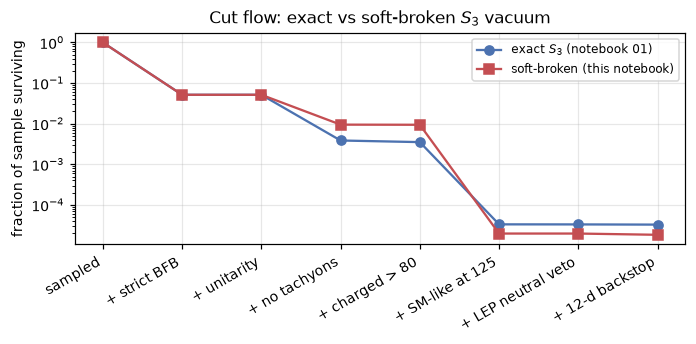

In [ ]:
exact = json.loads(Path("results/viable_points.json").read_text())
soft = payload
labels = scan_soft.CUT_LABELS
fe = [exact["cut_flow"][k] / exact["cut_flow"]["sampled"] for k in labels]
fs = [soft["cut_flow"][k] / soft["cut_flow"]["sampled"] for k in labels]

print("%-22s %14s %14s" % ("cut", "exact S3", "soft-broken"))
for k, a, b in zip(labels, fe, fs):
    print("%-22s %14.3e %14.3e" % (k, a, b))
print("\nsurvivors: exact %d / %.0e sampled,  soft %d / %.0e sampled"
      % (exact["n_points"], exact["sample_size"], soft["n_points"], soft["sample_size"]))

fig, ax = plt.subplots(figsize=(6.4, 3.2))
x = np.arange(len(labels))
ax.semilogy(x, fe, "o-", label=r"exact $S_3$ (notebook 01)", color="#4C72B0")
ax.semilogy(x, fs, "s-", label="soft-broken (this notebook)", color="#C44E52")
ax.set_xticks(x, labels, rotation=30, ha="right")
ax.set_ylabel("fraction of sample surviving")
ax.set_title(r"Cut flow: exact vs soft-broken $S_3$ vacuum")
ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

assert fe[1] == fe[2] and fs[1] == fs[2]      # unitarity adds nothing after strict BFB, in both
assert abs(fe[1] - fs[1]) < 5e-3               # the quartic cuts see the same lambda prior

The quartic cuts remove the same 95% in both scans, as they must: the λ prior is the same
and the soft terms never enter them. The two scans part ways at the spectrum.

* **No tachyons passes 2.5× more often** ($9.5\times10^{-3}$ against $3.9\times10^{-3}$). In
  the exact model every mass is a quartic times $v^2$, so a λ point with a negative
  combination is tachyonic whatever θ is. Soft terms add mass² of their own and lift those
  directions.
* **The coupling cut is where the soft space dies.** A state carrying at least 90% of the SM
  $hVV$ strength at 125 ± 3 GeV is a codimension-one condition in a 13-dimensional space,
  against 9 in the exact scan. The final survival fraction per sample is lower
  ($1.8\times10^{-5}$ against $3.3\times10^{-5}$), which says as much about the extra prior
  volume as about physics.

### 6.2 The spectrum

soft      min / median / max  [GeV]   exact     min / median / max  [GeV]
h1         34.0     125.1     128.0   H2          6.7     125.0     128.0
h2        123.6     587.5    2418.7   h0          4.5     325.5     521.0
h3        381.7     982.9   59817.5   H1        122.0     370.4     848.8
A1         55.4     595.3    2419.4   A1          1.6     333.4     670.9
A2        304.0     989.5   59817.7   A2         23.7     327.4     708.0
Hpm1       84.6     554.9    2413.8   Hpm1       81.2     241.2     469.9
Hpm2      245.9     968.2   59817.4   Hpm2       80.5     254.0     742.9


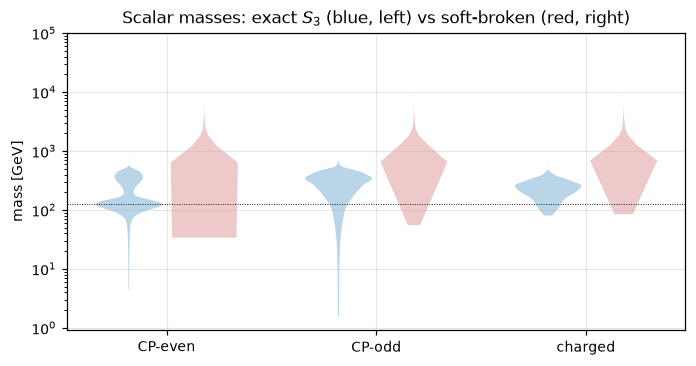

In [ ]:
P_s = soft["points"]; P_e = exact["points"]
ms_arr = {k: np.array([p["masses_GeV"][k] for p in P_s]) for k in SOFT_SPECTRUM_KEYS}
me_arr = {k: np.array([p["masses_GeV"][k] for p in P_e]) for k in SPECTRUM_KEYS}

print("%-6s %28s   %-6s %28s" % ("soft", "min / median / max  [GeV]", "exact", "min / median / max  [GeV]"))
pair = [("h1", "H2"), ("h2", "h0"), ("h3", "H1"), ("A1", "A1"), ("A2", "A2"),
        ("Hpm1", "Hpm1"), ("Hpm2", "Hpm2")]
for ks, ke in pair:
    a, b = ms_arr[ks], me_arr[ke]
    print("%-6s %8.1f %9.1f %9.1f   %-6s %8.1f %9.1f %9.1f"
          % (ks, a.min(), np.median(a), a.max(), ke, b.min(), np.median(b), b.max()))

fig, ax = plt.subplots(figsize=(6.4, 3.4))
names = ["CP-even", "CP-odd", "charged"]
soft_groups = [np.r_[ms_arr["h1"], ms_arr["h2"], ms_arr["h3"]],
               np.r_[ms_arr["A1"], ms_arr["A2"]], np.r_[ms_arr["Hpm1"], ms_arr["Hpm2"]]]
exact_groups = [np.r_[me_arr["h0"], me_arr["H1"], me_arr["H2"]],
                np.r_[me_arr["A1"], me_arr["A2"]], np.r_[me_arr["Hpm1"], me_arr["Hpm2"]]]
pos = np.arange(3)
ax.violinplot(exact_groups, pos - 0.18, widths=0.32, showextrema=False)
v2p = ax.violinplot(soft_groups, pos + 0.18, widths=0.32, showextrema=False)
for b in v2p["bodies"]:
    b.set_facecolor("#C44E52")
ax.set_xticks(pos, names); ax.set_yscale("log"); ax.set_ylabel("mass [GeV]")
ax.axhline(125, color="k", lw=0.6, ls=":")
ax.set_title("Scalar masses: exact $S_3$ (blue, left) vs soft-broken (red, right)")
plt.tight_layout(); plt.show()

The exact scan's spectrum is capped: every mass² is $\lambda\times v^2$ with $|\lambda|\le2$,
so nothing goes much past 850 GeV. With soft terms the heavy states are set by the soft scale
and reach TeV and beyond. The extreme tail, tens of TeV, comes entirely from the
$\varphi\to0$ edge, where the tadpole-fixed $m_{D1}^2\propto1/(v_1v_2)$ blows up (§6.4). The
lower ends matter more, and those are the next cell's subject.

### 6.3 No state is gauge-phobic, but the others are nearly so

SM-like state is h1 / h2 / h3 in [2015, 6, 0] of the points
kappa^2 of the SM-like state   : min 0.9003, median 0.9976
hVV^2 of the other two states  : median 4.00e-04, 90% below 1.52e-02, max 9.85e-02
points with a CP-even state below the SM-like one: 6 of 2021
  their hVV^2: max 3.57e-02 (LEP floor 0.05)


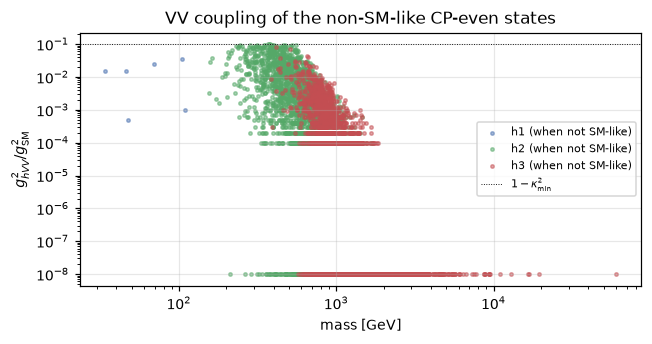


heaviest scalar, median: exact 439 GeV, soft 1001 GeV (soft above 1 TeV: 50%)
relative spread of (h3, A2, Hpm2): median 0.037; for h3 > 1 TeV 0.015
points with a non-SM scalar below 100 GeV: exact 15.8%, soft 0.7%
lambda_4 > 0: exact 100.0% of points, soft 50.6%


In [ ]:
hv = np.array([[p["hvv_squared"][k] for k in SOFT_CP_EVEN_KEYS] for p in P_s])
mass_even = np.array([[p["masses_GeV"][k] for k in SOFT_CP_EVEN_KEYS] for p in P_s])
carrier = hv.argmax(axis=1)
print("SM-like state is h1 / h2 / h3 in %s of the points"
      % np.bincount(carrier, minlength=3).tolist())
others = np.sort(np.where(np.eye(3, dtype=bool)[carrier], np.nan, hv), axis=1)[:, :2]
print("kappa^2 of the SM-like state   : min %.4f, median %.4f" %
      (hv.max(axis=1).min(), np.median(hv.max(axis=1))))
print("hVV^2 of the other two states  : median %.2e, 90%% below %.2e, max %.2e"
      % (np.nanmedian(others), np.nanpercentile(others, 90), np.nanmax(others)))
light = mass_even < 125.0 - 3.0
print("points with a CP-even state below the SM-like one: %d of %d"
      % (int(light.any(axis=1).sum()), len(P_s)))
if light.any():
    print("  their hVV^2: max %.2e (LEP floor %.2f)" % (hv[light].max(), XI2_LEP_FLOOR))

fig, ax = plt.subplots(figsize=(6.0, 3.2))
for j, c in zip(range(3), ("#4C72B0", "#55A868", "#C44E52")):
    sel = carrier != j
    ax.scatter(mass_even[sel, j], np.clip(hv[sel, j], 1e-8, None), s=5, alpha=0.5,
               color=c, label=f"h{j+1} (when not SM-like)")
ax.set_xscale("log"); ax.set_yscale("log")
ax.set_xlabel("mass [GeV]"); ax.set_ylabel(r"$g^2_{hVV}/g^2_{\rm SM}$")
ax.axhline(1 - KAPPA2_MIN, color="k", lw=0.6, ls=":", label=r"$1-\kappa^2_{\min}$")
ax.set_title("VV coupling of the non-SM-like CP-even states")
ax.legend(fontsize=7); plt.tight_layout(); plt.show()

heavy = np.array([[p["masses_GeV"][k] for k in ("h3", "A2", "Hpm2")] for p in P_s])
spread = (heavy.max(1) - heavy.min(1)) / heavy.max(1)
print("\nheaviest scalar, median: exact %.0f GeV, soft %.0f GeV (soft above 1 TeV: %.0f%%)"
      % (np.median([max(p["masses_GeV"].values()) for p in P_e]),
         np.median(heavy.max(1)), 100 * np.mean(heavy.max(1) > 1000)))
print("relative spread of (h3, A2, Hpm2): median %.3f; for h3 > 1 TeV %.3f"
      % (np.median(spread), np.median(spread[heavy[:, 0] > 1000])))
def light_frac(P, sm_keys):
    return np.mean([min(v for k, v in p["masses_GeV"].items()
                        if not (k in sm_keys and abs(v - 125) <= 3)) < 100 for p in P])
print("points with a non-SM scalar below 100 GeV: exact %.1f%%, soft %.1f%%"
      % (100 * light_frac(P_e, ("H1", "H2")), 100 * light_frac(P_s, SOFT_CP_EVEN_KEYS)))
l4e = np.array([p["lambdas"]["lambda_4"] for p in P_e])
l4s = np.array([p["lambdas"]["lambda_4"] for p in P_s])
print("lambda_4 > 0: exact %.1f%% of points, soft %.1f%%" % (100 * (l4e > 0).mean(),
                                                            100 * (l4s > 0).mean()))

The printed numbers say three things.

1. **The SM-like state is the lightest CP-even state** in 2015 of 2021 points. In the exact
   scan the gauge-phobic $h_0$ was free to sit below it, and was, in 7% of the points.
2. **The spectrum is decoupling-like.** The heaviest CP-even, CP-odd and charged states are
   near-degenerate: their relative spread has a median of 4%, and 1.5% above 1 TeV. This is
   the pattern of a heavy doublet whose mass comes from one large soft term, the same pattern
   as the 2HDM's large-$m_{12}^2$ regime. The non-SM CP-even states couple to $VV$ at the
   $10^{-4}$ level (median), and never above $1-\kappa^2_{\min}=0.1$, since the three overlaps
   share the SM strength.
3. **The exact scan's light scalars do not survive generic soft breaking.** In the exact scan
   16% of points have a non-SM scalar below 100 GeV, allowed by LEP because $h_0$ is exactly
   gauge-phobic and $A$/$H^\pm$ do not couple to $ZZ$. Here it is 0.7%. The light states are
   a property of the measure-zero exact slice, not of the S₃ quartics.

A side result: **λ₄ > 0 in every exact-scan point, and in half of the soft ones.** With the
alignment and $v_{1,2}>0$ fixed, the λ₄ < 0 aligned vacua are all excluded by the cuts (this
is observed over the 1964 points, not derived here). Releasing φ lets either sign through.

### 6.4 How much breaking do viable points need?

max |soft m^2| / v^2 over the four soft terms:
   min 0.40   median 4.06   90% 38.8   max 29559.8
   (the free soft terms alone reach at most 4.13; larger values come from the solved mD1^2)
points with every soft term below 0.5 v^2 : 1
points with every soft term below 1.0 v^2 : 15
points within 5 deg of the exact-S3 vacuum : 237
survivors per 5-deg bin of phi (uniform prior): [261, 235, 187, 118, 108, 107, 93, 109, 144, 181, 241, 237]
points within 2 deg of the quark-fit vacuum (phi = 53.44 deg): 205
the 15 points with every soft term below v^2: lightest non-h1 scalar 84 GeV, heaviest 629 GeV


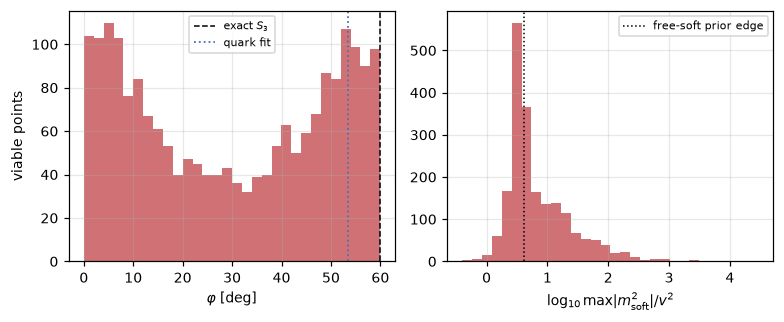

In [ ]:
brk = np.array([p["breaking"]["max_soft_over_v2"] for p in P_s])
phi_s = np.array([p["phi"] for p in P_s])
mD1 = np.array([p["softs_GeV2"]["mD1sq"] for p in P_s])

free_max = scan_soft.SOFT_MASS**2 / V_EW**2
print("max |soft m^2| / v^2 over the four soft terms:")
print("   min %.2f   median %.2f   90%% %.1f   max %.1f" %
      (brk.min(), np.median(brk), np.percentile(brk, 90), brk.max()))
print("   (the free soft terms alone reach at most %.2f; larger values come from the solved mD1^2)"
      % free_max)
print("points with every soft term below 0.5 v^2 : %d" % int((brk < 0.5).sum()))
print("points with every soft term below 1.0 v^2 : %d" % int((brk < 1.0).sum()))
print("points within 5 deg of the exact-S3 vacuum : %d" %
      int((phi_s > math.pi / 3 - math.radians(5)).sum()))
print("survivors per 5-deg bin of phi (uniform prior):",
      np.histogram(np.degrees(phi_s), bins=12, range=(0, 60))[0].tolist())
print("points within 2 deg of the quark-fit vacuum (phi = %.2f deg): %d"
      % (math.degrees(phi_fit), int((np.abs(phi_s - phi_fit) < math.radians(2)).sum())))
low = brk < 1.0
lightest_nonSM = np.array([min(v for k, v in p["masses_GeV"].items() if k != "h1")
                           for p in P_s])
print("the %d points with every soft term below v^2: lightest non-h1 scalar %.0f GeV, "
      "heaviest %.0f GeV" % (int(low.sum()), lightest_nonSM[low].min(),
                             max(max(p["masses_GeV"].values()) for p in np.array(P_s)[low])))

fig, axs = plt.subplots(1, 2, figsize=(7.2, 3.0))
axs[0].hist(np.degrees(phi_s), bins=30, color="#C44E52", alpha=0.8)
axs[0].axvline(60, color="k", ls="--", lw=1, label=r"exact $S_3$")
axs[0].axvline(math.degrees(phi_fit), color="#4C72B0", ls=":", lw=1.2, label="quark fit")
axs[0].set_xlabel(r"$\varphi$ [deg]"); axs[0].set_ylabel("viable points"); axs[0].legend(fontsize=7)
axs[1].hist(np.log10(brk), bins=30, color="#C44E52", alpha=0.8)
axs[1].axvline(np.log10(free_max), color="k", ls=":", lw=1, label="free-soft prior edge")
axs[1].set_xlabel(r"$\log_{10}\max|m^2_{\rm soft}|/v^2$"); axs[1].legend(fontsize=7)
plt.tight_layout(); plt.show()

**No viable point is close to exact S₃ in both senses at once.** The largest soft term is at
least $0.40\,v^2$, with a median of $4v^2$. Only 15 of 2021 points keep every soft term below
$v^2$. Their spectra (a lightest non-SM scalar of about 85 GeV, everything else in
250–650 GeV) look like the exact scan's heavy states, without its very light ones. Some of this
is the prior: a uniform box in $m^2$ gives little volume to small values. What the scan does
show is that small breaking is *allowed*, including at points within a few degrees of
$\varphi=60°$, and that the viable region does not collapse onto the exact vacuum as the
breaking shrinks. It just becomes rare under this measure. A log-uniform scan targeted at the
near-S₃ corner would resolve it. That is left as an open item, not claimed.

**φ.** Survivors pile up at **both** ends of the domain, the two residual-$\mathbb Z_2$
directions (261 in the first 5° bin, 237 in the last, against about 95 in the middle). The
notebook-02 quark-fit vacuum at 53.4° lies in the well-populated upper range.

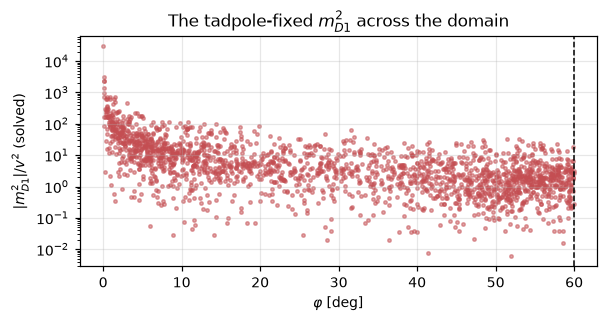

points with a state above 2000 GeV: 273, of which at phi < 7 deg: 63%
points with a state above 5000 GeV: 34, of which at phi < 7 deg: 100%
within 10 deg of phi = 60 deg: 478 points, max|soft|/v^2 median 3.46, min 0.40


In [ ]:
# where does the breaking come from?  The solved mD1^2 ~ 1/(v1 v2): it blows up
# at the phi -> 0 edge, so the largest tags are a phi-edge effect.
order = np.argsort(phi_s)
fig, ax = plt.subplots(figsize=(5.6, 3.0))
ax.scatter(np.degrees(phi_s), np.abs(mD1) / V_EW**2, s=5, alpha=0.5, color="#C44E52")
ax.set_yscale("log"); ax.set_xlabel(r"$\varphi$ [deg]"); ax.set_ylabel(r"$|m^2_{D1}|/v^2$ (solved)")
ax.axvline(60, color="k", ls="--", lw=1)
ax.set_title(r"The tadpole-fixed $m_{D1}^2$ across the domain")
plt.tight_layout(); plt.show()
near = phi_s > math.pi / 3 - math.radians(10)
if near.any():
    heavy_max = np.array([max(p["masses_GeV"].values()) for p in P_s])
for t in (2000, 5000):
    sel = heavy_max > t
    print("points with a state above %d GeV: %d, of which at phi < 7 deg: %.0f%%"
          % (t, int(sel.sum()), 100 * np.mean(phi_s[sel] < math.radians(7))))
print("within 10 deg of phi = 60 deg: %d points, max|soft|/v^2 median %.2f, min %.2f"
          % (int(near.sum()), np.median(brk[near]), brk[near].min()))

The $\varphi\to0$ pile-up is the decoupling tail. $m_{D1}^2\propto1/(v_1v_2)$ grows without
bound there. All 34 points with a state above 5 TeV sit at $\varphi<7°$, as do 63% of
those above 2 TeV. The
$\varphi\to60°$ pile-up is the physically interesting one: moderate breaking (median $3.5v^2$
within 10°) around the vacuum the exact model is forced into.

---
## 7. Findings

1. **Soft ≠ small, and the scan treats it so.** Soft breaking is fixed by operator dimension.
   The spurions renormalize only in proportion to themselves, so small values are technically
   natural ['tHooft80], but large ones are equally consistent. The soft terms were sampled
   wide, with breaking size tagged per point.
2. **A parametrization trap, fixed.** Solving the tadpoles for $m_{D2}^2$ (the `build_model`
   default) divides by $v_1^2-v_2^2$, which puts a pole at $\varphi=45°$ in the middle of the
   domain. Solving for $m_{D1}^2$ divides only by $v_1v_2$ (`soft_solve_for="mD1sq"`).
3. **φ ∈ (0, π/3) is a fundamental domain**, and each point stands for two draft-basis ratios,
   $r=-\cot(\varphi-\pi/6)$ and $-\tan\varphi$. Notebook 02's quark-fit vacuum
   ($|r|=1.349$) is φ = 53.44° here.
4. **The machinery generalizes cleanly.** $R$ still isolates both Goldstones (exact zeros).
   The CP-even sector is a full 3×3 with no gauge-phobic state, the hVV sum rule holds to
   $10^{-15}$, brute-force diagonalization agrees in all three sectors, and the aligned,
   zero-soft slice reproduces notebook 01 to $10^{-10}$.
5. **2021 viable points from $1.1\times10^8$** (`results/viable_points_soft.json`). Quartic
   cuts are identical to notebook 01's. No tachyons passes 2.5× more often, and the coupling
   cut at 125 GeV is where the soft space dies.
6. **The soft-broken spectrum is decoupling-like.** The SM-like state is the lightest CP-even
   state (99.7%), and the heavy states are near-degenerate triplets reaching TeV (heaviest
   median 1.0 TeV against 0.44 TeV exact). Non-SM CP-even states couple to $VV$ at the
   $10^{-4}$ level.
7. **The exact scan's light, gauge-phobic scalars are a measure-zero feature.** A non-SM
   scalar below 100 GeV appears in 16% of exact points and 0.7% of soft ones. λ₄ > 0 is
   likewise exact-scan-only (100% against 51%).
8. **Caveats.** A uniform prior in $m^2$ barely populates the near-S₃ corner (15 points with
   every soft term below $v^2$). The vacuum is required to be a **local** minimum only. The
   decays/LFV of notebook 03 are not redone here: its δ-parametrization assumed the aligned
   2×2 CP-even block, and the soft CP-even mixing is a full 3×3 (`cp_even_mixing` in the
   JSON).

In [ ]:
ledger.step(r"$\varphi\in(0,\pi/3)$ is a fundamental domain: $\varphi\to2\pi/3-\varphi$ with "
            r"$P$ on both spurion doublets is the same physics",
            obtained="derived",
            checks=(r"identical spectra and solved $m_{D1}^2$ at 200 random image pairs",
                    r"leaving the $\mathbf2$ spurion untransformed breaks it"),
            falsified_by=r"a spectrum differing between a point and its image",
            section="3")
ledger.step(r"The draft-basis vacuum ratio is $r=-\cot(\varphi-\pi/6)$",
            obtained="derived",
            checks=(r"agrees with \texttt{fermions.tex\_basis\_map} at 40 angles",
                    r"$|r(\pi/3)|=\sqrt3$; the quark-fit $|r|$ lies inside the domain"),
            falsified_by=r"disagreement with the verified basis map",
            section="3")
ledger.step(r"Soft terms need not be small: they renormalize only in proportion to themselves",
            obtained="imported",
            checks=(r"technical naturalness ['tHooft80]: small soft terms are stable, "
                    r"large ones equally consistent",),
            section="1")
ledger.table()
ledger.to_latex("derivations_05.tex",
                subtitle="the soft-broken vacuum: tadpoles, fundamental domain, spectrum")

### Derivation ledger — 05 — S₃-3HDM scalar parameter space in the soft-broken vacuum

**1. The soft-broken tadpoles fix $(\mu_0^2,\mu_1^2,m_{D1}^2)$ for a general vacuum**  
<sub>derived here &nbsp;·&nbsp; §2</sub>

- ✓ solving for $m_{D2}^2$ instead divides by $v_1^2-v_2^2$ (singular at $\varphi=45^\circ$); $m_{D1}^2$ divides by $v_1v_2$ only
- ✓ at $v_2=\sqrt3v_1$ with the free soft terms off, $m_{D1}^2=0$

*Would be falsified by:* a non-zero $m_{D1}^2$ on the aligned, zero-soft vacuum


---

**2. For a general vacuum $R$ still isolates both Goldstones; the CP-even sector is a full $3\times3$ with no gauge-phobic state**  
<sub>derived here &nbsp;·&nbsp; §4</sub>

- ✓ first rows of $R^{\mathsf T}M_{A,C}R$ vanish exactly at a rational point
- ✓ masses match sympy eigenvals of the un-rotated matrices, 60 points
- ✓ $\sum_k g_{h_kVV}^2/g_{\rm SM}^2=1$ to $10^{-12}$

*Would be falsified by:* a non-zero Goldstone row, or a mass disagreeing with brute force


---

**3. $\varphi\in(0,\pi/3)$ is a fundamental domain: $\varphi\to2\pi/3-\varphi$ with $P$ on both spurion doublets is the same physics**  
<sub>derived here &nbsp;·&nbsp; §3</sub>

- ✓ identical spectra and solved $m_{D1}^2$ at 200 random image pairs
- ✓ leaving the $\mathbf2$ spurion untransformed breaks it

*Would be falsified by:* a spectrum differing between a point and its image


---

**4. The draft-basis vacuum ratio is $r=-\cot(\varphi-\pi/6)$**  
<sub>derived here &nbsp;·&nbsp; §3</sub>

- ✓ agrees with \texttt{fermions.tex\_basis\_map} at 40 angles
- ✓ $|r(\pi/3)|=\sqrt3$; the quark-fit $|r|$ lies inside the domain

*Would be falsified by:* disagreement with the verified basis map


---

**5. Soft terms need not be small: they renormalize only in proportion to themselves**  
<sub>**imported** &nbsp;·&nbsp; §1</sub>

- ✓ technical naturalness ['tHooft80]: small soft terms are stable, large ones equally consistent

---

<sub>5 steps: 4 derived here, 1 imported, 0 assumed</sub>

wrote derivations_05.tex  (5 steps)


'derivations_05.tex'

---
## 8. References

- **['tHooft80]** G. 't Hooft, *"Naturalness, chiral symmetry, and spontaneous chiral
  symmetry breaking"*, in *Recent Developments in Gauge Theories* (Cargèse 1979), NATO Sci.
  Ser. B **59**, 135 (1980),
  [doi:10.1007/978-1-4684-7571-5_9](https://doi.org/10.1007/978-1-4684-7571-5_9). The
  technical-naturalness criterion of §1: a parameter may be small if setting it to zero
  enlarges the symmetry.
- **[GomezBock21]** M. Gómez-Bock, M. Mondragón, A. Pérez-Martínez, *"Scalar and gauge
  sectors in the 3-Higgs Doublet Model under the S₃-symmetry"*, Eur. Phys. J. C **81**, 942
  (2021), [arXiv:2102.02800](https://arxiv.org/abs/2102.02800). Eq. (29), the geometric
  rotation of §4.
- **[DasDeyPal16]** D. Das, U. K. Dey, P. B. Pal, *"S₃ symmetry and the quark mixing
  matrix"*, Phys. Lett. B **753**, 315 (2016), [arXiv:1507.06509](https://arxiv.org/abs/1507.06509).
  Soft S₃ breaking as the source of CKM mixing, the motivation this notebook follows up.
- **[LEP2003]**, **[DasDey14]**: as in notebook 01 (boundedness, unitarity and the neutral
  veto are applied unchanged).